# Section 5 — Classification Models

**Objective:** Classify vehicles as **Fuel Efficient (1)** or **Not Efficient (0)** based on their physical and mechanical attributes, and extract actionable business insights regarding what vehicle properties contribute most to fuel efficiency.

**Key Design Decision — Type-Specific Residual-Based Efficiency:**  
Different vehicle types operate in different driving contexts. Following the team's decision, we evaluate each type against its most relevant fuel consumption metric:

| Vehicle Type | Target Metric | Rationale |
|---|---|---|
| SMALL (compact, subcompact, etc.) | City consumption | Primarily urban driving |
| MIDDLE (mid-size, full-size) | Combined consumption | Mixed driving patterns |
| VAN (SUVs, minivans) | Combined consumption | Mixed driving patterns |
| LARGE (trucks, vans, specialty) | Highway consumption | Primarily highway/hauling |

For each type, we fit a linear regression to predict the relevant consumption, then label vehicles whose **actual consumption falls below the predicted value** as efficient — meaning they outperform expectations *for their type and configuration*.

**Models:**
- **Logistic Regression** — interpretable linear baseline.
- **Random Forest** — captures non-linear feature interactions.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score,
                             r2_score, mean_absolute_error)

sns.set_style('whitegrid')
print('All modules imported successfully.')

All modules imported successfully.


## 2. Data Preparation

We load `Use dataset.csv` from Phase 2 and reproduce the vehicle type mapping. The dataset has already undergone duplicate removal (Phase 1), feature engineering (transmission splitting, one-hot encoding), and the new 4-type vehicle classification.

In [3]:
# Load pre-processed dataset from Phase 2
df = pd.read_csv('../Data/Regression dataset.csv')
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
print(f'\nVehicle Type distribution:')
print(df['Type'].value_counts())

Loaded: 4932 rows x 15 columns
Columns: ['Engine Size(L)', 'Cylinders', 'Type', 'Gear num', 'Transmission Type_AM', 'Transmission Type_AS', 'Transmission Type_AV', 'Transmission Type_M', 'Fuel Type_E', 'Fuel Type_N', 'Fuel Type_X', 'Fuel Type_Z', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)']

Vehicle Type distribution:
Type
SMALL     1644
MIDDLE    1403
VAN       1285
LARGE      600
Name: count, dtype: int64


## 3. Target Variable Definition — Type-Specific Residual Approach

### 3.1 Rationale

Rather than applying a single global threshold, we recognise that different vehicle types serve different purposes and should be evaluated against different benchmarks:

1. **For each vehicle type**, fit a linear regression predicting the type-appropriate fuel consumption metric from vehicle attributes.
2. **Compute residuals**: residual = actual − predicted.
3. **Label**: residual < 0 → **Efficient** (consumes less than expected for its type and configuration).

This captures *relative* efficiency: a pickup truck that outperforms expectations on highway fuel consumption is efficient, even if its absolute consumption is higher than a compact car.

In [4]:
# Define type-specific target columns
target_map = {
    'SMALL':  'Fuel Consumption City (L/100 km)',      # Urban-focused vehicles
    'MIDDLE': 'Fuel Consumption Comb (L/100 km)',      # Mixed-use vehicles
    'VAN':    'Fuel Consumption Comb (L/100 km)',      # Mixed-use vehicles
    'LARGE':  'Fuel Consumption Hwy (L/100 km)'       # Highway/hauling vehicles
}

fuel_cols = [
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)'
]

# Fit per-type linear regression and compute residuals
df['Is_Efficient'] = 0
regression_results = {}

print('Per-Type Linear Regression Performance:')
print('-' * 75)

for vtype, target_col in target_map.items():
    mask = df['Type'] == vtype
    sub = df[mask]
    
    # Features: everything except fuel consumption columns and Type
    feat = sub.drop(columns=fuel_cols + ['Type'])
    target = sub[target_col]
    
    # Fit regression
    reg = LinearRegression()
    reg.fit(feat, target)
    predicted = reg.predict(feat)
    residuals = target.values - predicted
    
    # Store results
    r2 = r2_score(target, predicted)
    mae = mean_absolute_error(target, predicted)
    regression_results[vtype] = {
        'reg': reg, 'predicted': predicted, 'residuals': residuals,
        'actual': target.values, 'r2': r2, 'target_col': target_col
    }
    
    # Label: actual < predicted → Efficient
    df.loc[mask, 'Is_Efficient'] = (residuals < 0).astype(int)
    
    n_eff = int((residuals < 0).sum())
    print(f'  {vtype:6s} | Target: {target_col:42s} | '
          f'R2={r2:.4f} | MAE={mae:.2f} | '
          f'Efficient: {n_eff}/{len(sub)} ({n_eff/len(sub)*100:.1f}%)')

print('-' * 75)
n_total = df['Is_Efficient'].sum()
print(f'  Overall: Efficient = {n_total}/{len(df)} ({n_total/len(df)*100:.1f}%)')

Per-Type Linear Regression Performance:
---------------------------------------------------------------------------
  SMALL  | Target: Fuel Consumption City (L/100 km)           | R2=0.8407 | MAE=0.94 | Efficient: 884/1644 (53.8%)
  MIDDLE | Target: Fuel Consumption Comb (L/100 km)           | R2=0.8495 | MAE=0.77 | Efficient: 691/1403 (49.3%)
  VAN    | Target: Fuel Consumption Comb (L/100 km)           | R2=0.8389 | MAE=0.77 | Efficient: 653/1285 (50.8%)
  LARGE  | Target: Fuel Consumption Hwy (L/100 km)            | R2=0.7659 | MAE=0.95 | Efficient: 334/600 (55.7%)
---------------------------------------------------------------------------
  Overall: Efficient = 2562/4932 (51.9%)


### 3.2 Visualisation: Per-Type Predicted vs Actual

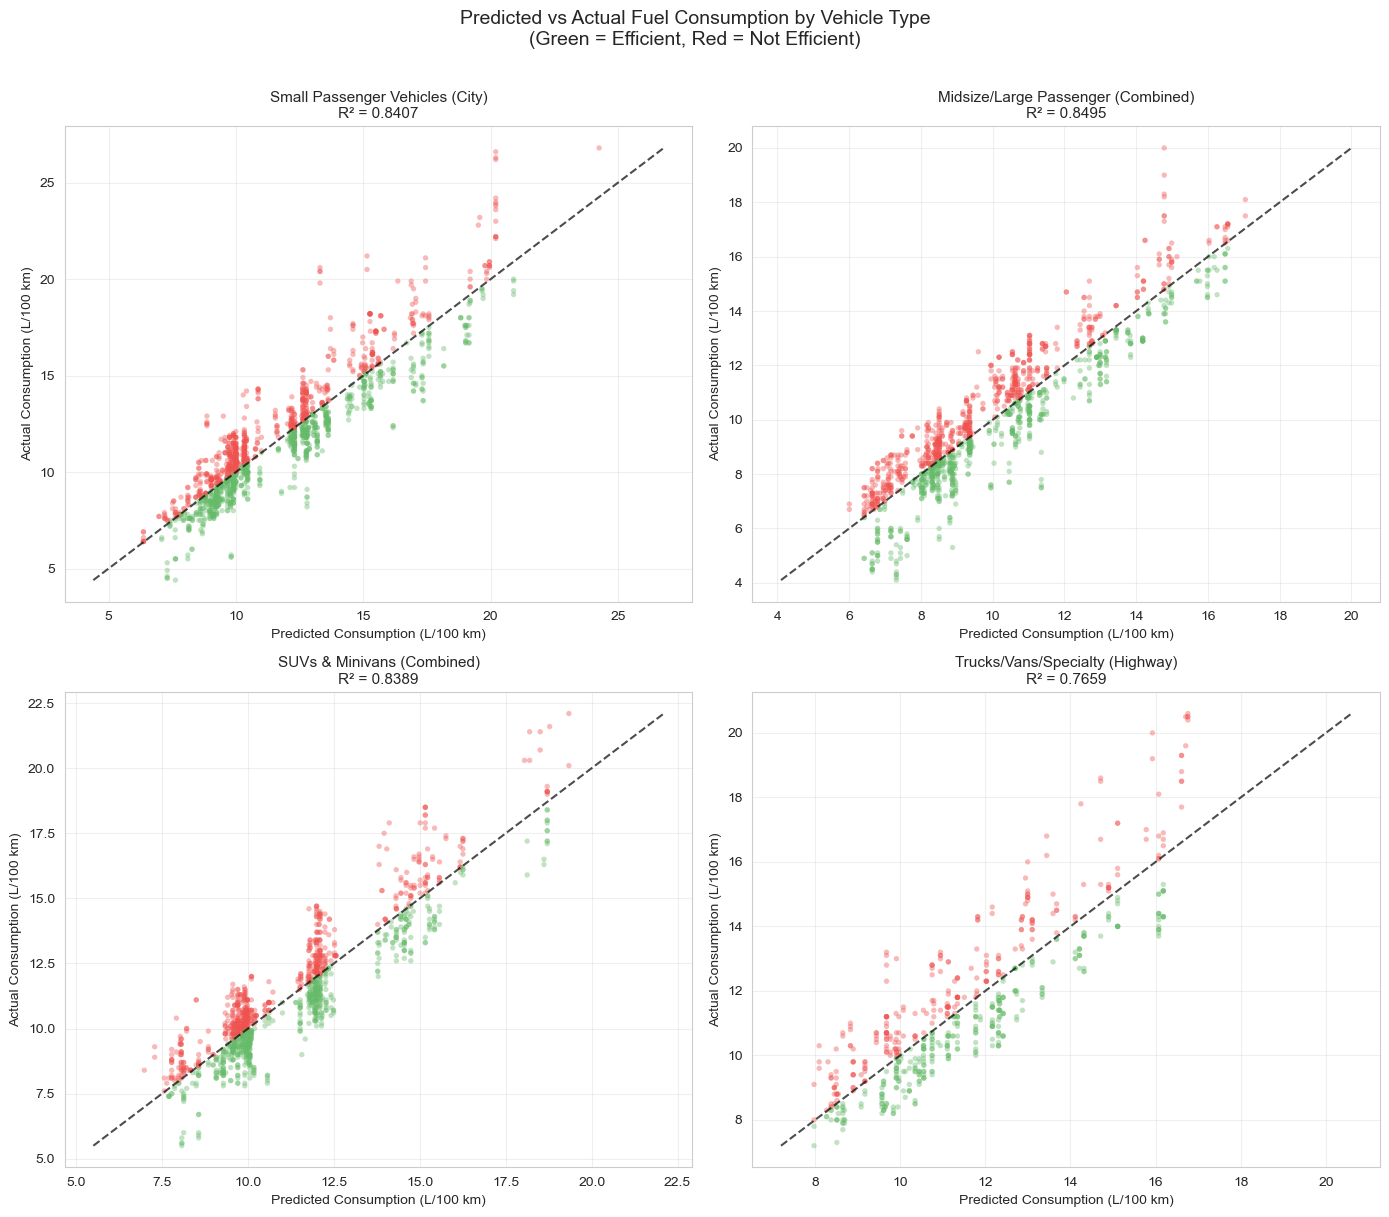

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
type_order = ['SMALL', 'MIDDLE', 'VAN', 'LARGE']
type_labels = {
    'SMALL': 'Small Passenger Vehicles (City)',
    'MIDDLE': 'Midsize/Large Passenger (Combined)',
    'VAN': 'SUVs & Minivans (Combined)',
    'LARGE': 'Trucks/Vans/Specialty (Highway)'
}

for ax, vtype in zip(axes.flat, type_order):
    res = regression_results[vtype]
    colors = ['#66BB6A' if r < 0 else '#EF5350' for r in res['residuals']]
    ax.scatter(res['predicted'], res['actual'], c=colors, alpha=0.4, s=15, edgecolors='none')
    
    lims = [min(res['predicted'].min(), res['actual'].min()),
            max(res['predicted'].max(), res['actual'].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Predicted Consumption (L/100 km)', fontsize=10)
    ax.set_ylabel('Actual Consumption (L/100 km)', fontsize=10)
    ax.set_title(f'{type_labels[vtype]}\nR² = {res["r2"]:.4f}', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual Fuel Consumption by Vehicle Type\n'
             '(Green = Efficient, Red = Not Efficient)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

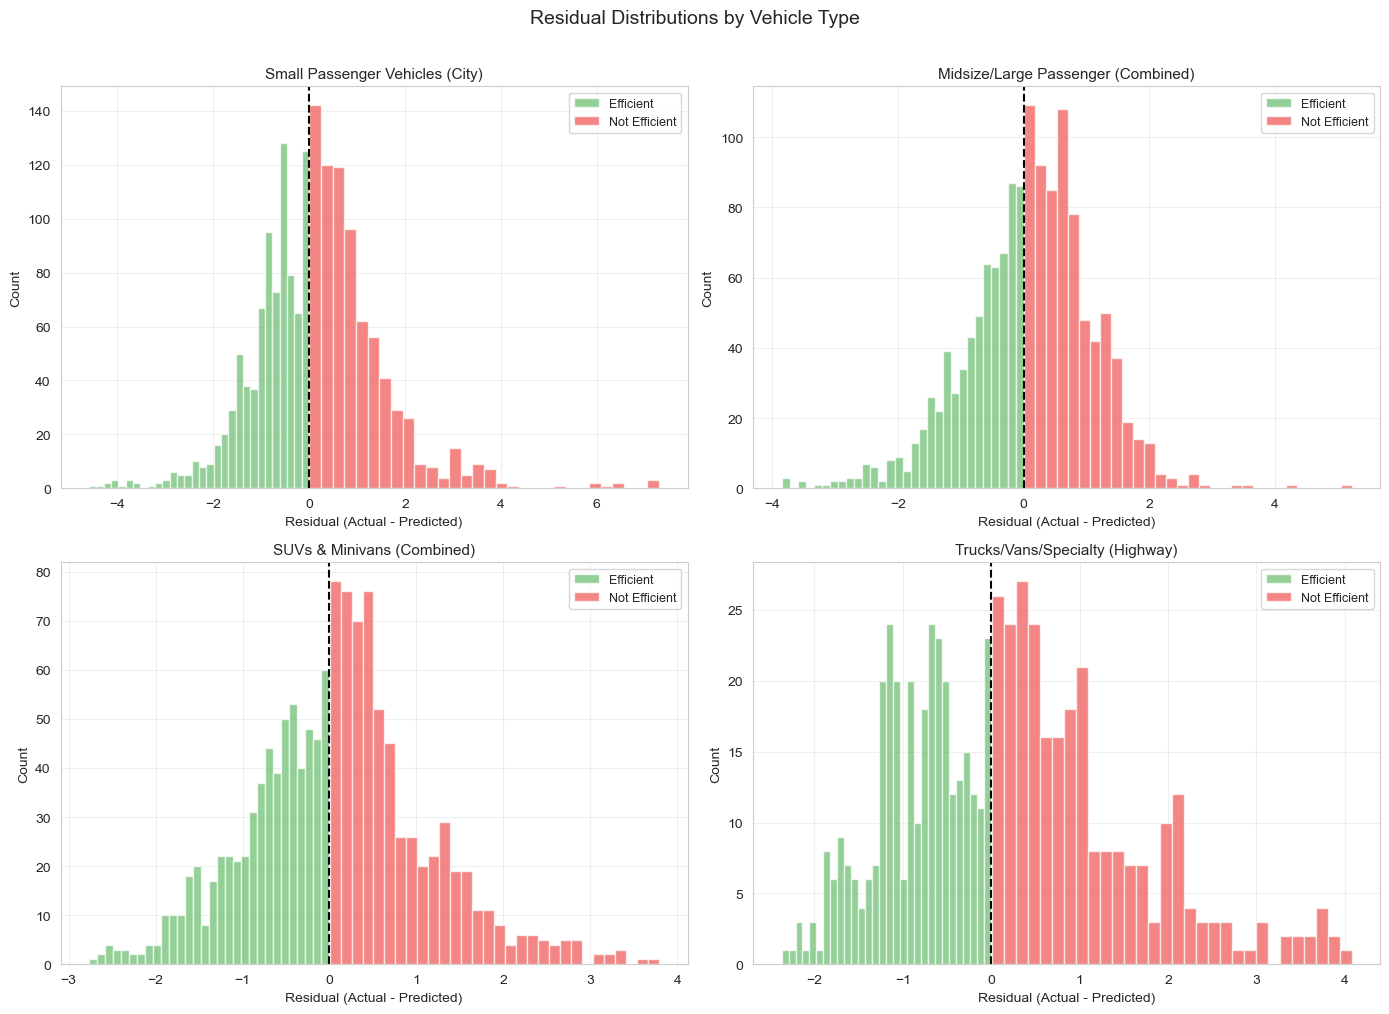

In [6]:
# Residual distribution by type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, vtype in zip(axes.flat, type_order):
    res = regression_results[vtype]
    r = res['residuals']
    ax.hist(r[r < 0], bins=30, color='#66BB6A', alpha=0.7, label='Efficient')
    ax.hist(r[r >= 0], bins=30, color='#EF5350', alpha=0.7, label='Not Efficient')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Residual (Actual - Predicted)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{type_labels[vtype]}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Residual Distributions by Vehicle Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

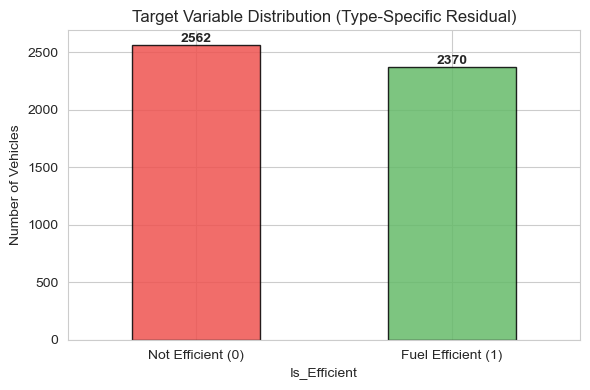

In [7]:
# Overall target distribution
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#EF5350', '#66BB6A']
df['Is_Efficient'].value_counts().plot(kind='bar', color=colors, edgecolor='black', alpha=0.85, ax=ax)
ax.set_xticklabels(['Not Efficient (0)', 'Fuel Efficient (1)'], rotation=0)
ax.set_ylabel('Number of Vehicles')
ax.set_title('Target Variable Distribution (Type-Specific Residual)')
for i, v in enumerate(df['Is_Efficient'].value_counts().values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Preparation & Train/Test Split

We include the `Type` column (one-hot encoded) as a classification feature. Since the residual-based target was computed using type-specific regressions with different target variables, the `Type` information is meaningful — it tells the classifier *which efficiency benchmark* was used for each vehicle.

In [8]:
# One-hot encode Type for classification
df_encoded = pd.get_dummies(df, columns=['Type'], drop_first=True, dtype=int)

# Features: exclude fuel consumption columns and target
X = df_encoded.drop(columns=fuel_cols + ['Is_Efficient'])
y = df_encoded['Is_Efficient']

print(f'Feature matrix: {X.shape[0]} samples x {X.shape[1]} features')
print(f'Features: {X.columns.tolist()}')

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Train balance - Efficient: {y_train.mean()*100:.1f}%')
print(f'Test  balance - Efficient: {y_test.mean()*100:.1f}%')

Feature matrix: 4932 samples x 14 features
Features: ['Engine Size(L)', 'Cylinders', 'Gear num', 'Transmission Type_AM', 'Transmission Type_AS', 'Transmission Type_AV', 'Transmission Type_M', 'Fuel Type_E', 'Fuel Type_N', 'Fuel Type_X', 'Fuel Type_Z', 'Type_MIDDLE', 'Type_SMALL', 'Type_VAN']

Training set: 3945 samples
Test set:     987 samples
Train balance - Efficient: 51.9%
Test  balance - Efficient: 52.0%


## 5. Model 1 — Logistic Regression

**Expected behaviour:** Since the per-type linear regressions have already captured the linear relationships between features and consumption (R² ≈ 0.77–0.85), the residuals are approximately orthogonal to the linear feature space. Logistic Regression, as a linear classifier, is therefore expected to struggle — this is not a flaw but an inherent consequence of the residual-based target.

In [9]:
# Hyperparameter tuning
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2']
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    lr_param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)
lr_grid.fit(X_train_scaled, y_train)

print(f'Best hyperparameters: {lr_grid.best_params_}')
print(f'Best CV F1 Score:     {lr_grid.best_score_:.4f}')

Best hyperparameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 Score:     0.6824


In [10]:
# Evaluate on test set
lr_model = lr_grid.best_estimator_
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression - Test Set Performance:')
print(classification_report(y_test, y_pred_lr,
                            target_names=['Not Efficient (0)', 'Fuel Efficient (1)']))

Logistic Regression - Test Set Performance:
                    precision    recall  f1-score   support

 Not Efficient (0)       0.55      0.10      0.17       474
Fuel Efficient (1)       0.53      0.93      0.67       513

          accuracy                           0.53       987
         macro avg       0.54      0.51      0.42       987
      weighted avg       0.54      0.53      0.43       987



In [11]:
# Cross-validation stability
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1 Scores: {np.round(lr_cv_scores, 4)}')
print(f'Mean: {lr_cv_scores.mean():.4f} +/- {lr_cv_scores.std():.4f}')

5-Fold CV F1 Scores: [0.6844 0.6858 0.6829 0.6725 0.6867]
Mean: 0.6825 +/- 0.0051


## 6. Model 2 — Random Forest

Random Forest can capture the **non-linear feature interactions** that remain after the linear regression has been subtracted. The performance gap between LR and RF directly quantifies how much of the efficiency signal is non-linear.

In [12]:
# Hyperparameter tuning
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)
rf_grid.fit(X_train, y_train)  # RF does not require scaling

print(f'Best hyperparameters: {rf_grid.best_params_}')
print(f'Best CV F1 Score:     {rf_grid.best_score_:.4f}')

Best hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 Score:     0.7590


In [13]:
# Evaluate on test set
rf_model = rf_grid.best_estimator_
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest - Test Set Performance:')
print(classification_report(y_test, y_pred_rf,
                            target_names=['Not Efficient (0)', 'Fuel Efficient (1)']))

Random Forest - Test Set Performance:
                    precision    recall  f1-score   support

 Not Efficient (0)       0.72      0.71      0.71       474
Fuel Efficient (1)       0.74      0.74      0.74       513

          accuracy                           0.73       987
         macro avg       0.73      0.73      0.73       987
      weighted avg       0.73      0.73      0.73       987



In [14]:
# Cross-validation stability
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1 Scores: {np.round(rf_cv_scores, 4)}')
print(f'Mean: {rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}')

5-Fold CV F1 Scores: [0.7259 0.7432 0.7722 0.769  0.7597]
Mean: 0.7540 +/- 0.0173


## 7. Model Comparison

In [15]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall':    [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_rf)],
    'F1 Score':  [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_rf)],
    'ROC-AUC':   [roc_auc_score(y_test, y_prob_lr),   roc_auc_score(y_test, y_prob_rf)],
    'CV F1 (mean +/- std)': [
        f'{lr_cv_scores.mean():.4f} +/- {lr_cv_scores.std():.4f}',
        f'{rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}'
    ]
})
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
results[display_cols] = results[display_cols].round(4)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV F1 (mean +/- std)
0,Logistic Regression,0.5289,0.5266,0.9259,0.6714,0.5125,0.6825 +/- 0.0051
1,Random Forest,0.7275,0.7355,0.7427,0.7391,0.8299,0.7540 +/- 0.0173


### 7.1 Confusion Matrices

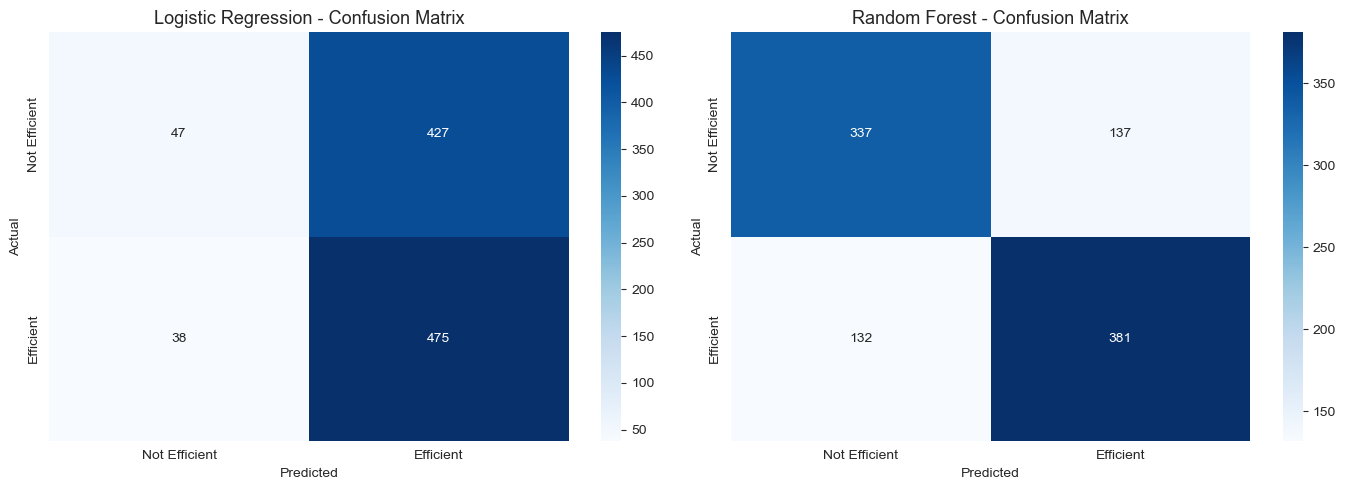

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_lr, y_pred_rf],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Efficient', 'Efficient'],
                yticklabels=['Not Efficient', 'Efficient'])
    ax.set_title(f'{title} - Confusion Matrix', fontsize=13)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

### 7.2 ROC Curves

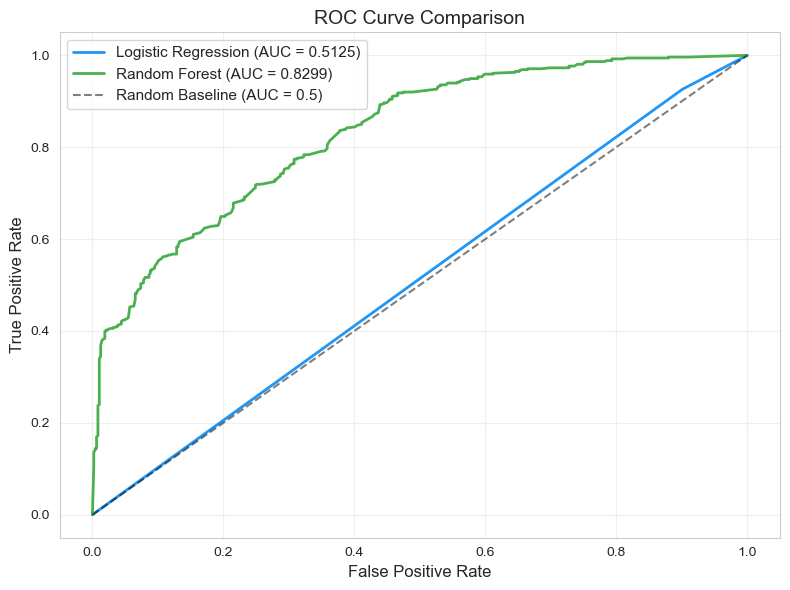

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, color in zip([y_prob_lr, y_prob_rf],
    ['Logistic Regression', 'Random Forest'], ['#2196F3', '#4CAF50']):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc_val:.4f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Performance Bar Chart

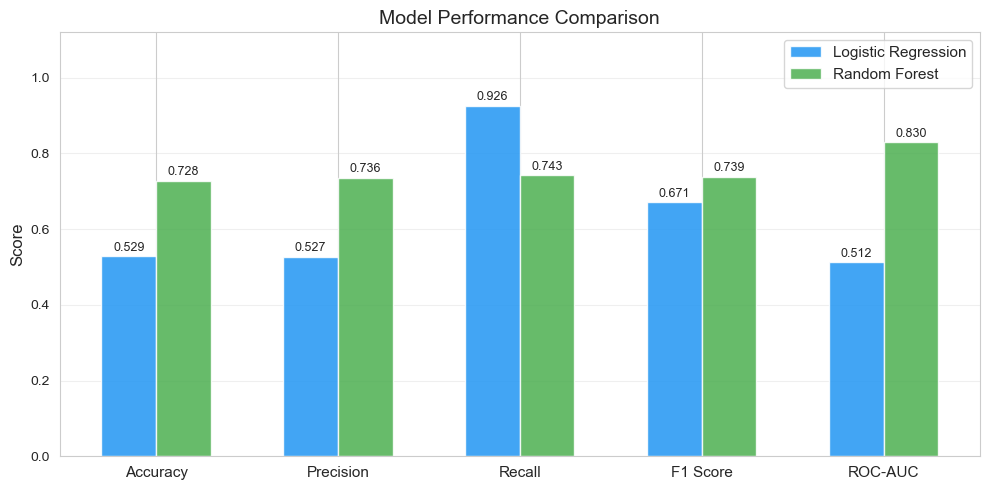

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.3
lr_vals = results[metrics].iloc[0].values.astype(float)
rf_vals = results[metrics].iloc[1].values.astype(float)
bars1 = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, rf_vals, width, label='Random Forest', color='#4CAF50', alpha=0.85)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x()+bar.get_width()/2, h),
                    xytext=(0,4), textcoords='offset points', ha='center', fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Cross-Validation Stability

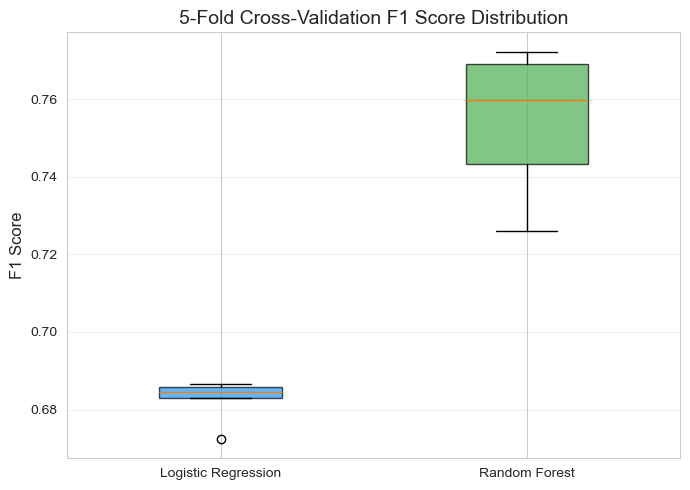

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot([lr_cv_scores, rf_cv_scores],
                tick_labels=['Logistic Regression', 'Random Forest'],
                patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#4CAF50')
for box in bp['boxes']: box.set_alpha(0.7)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation F1 Score Distribution', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Insight Extraction

### 8.1 Random Forest — Feature Importance

With the per-type residual target, feature importance now answers: *"Which features cause a vehicle to outperform its type-specific expected consumption?"*

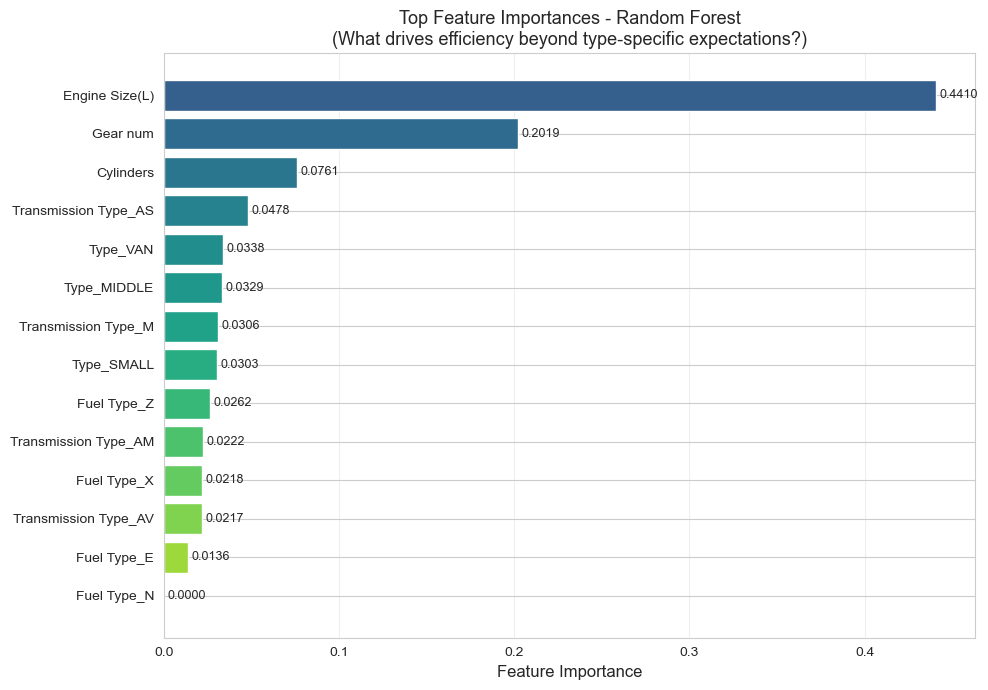

Top 10 features:
  1. Engine Size(L): 0.4410
  2. Gear num: 0.2019
  3. Cylinders: 0.0761
  4. Transmission Type_AS: 0.0478
  5. Type_VAN: 0.0338
  6. Type_MIDDLE: 0.0329
  7. Transmission Type_M: 0.0306
  8. Type_SMALL: 0.0303
  9. Fuel Type_Z: 0.0262
  10. Transmission Type_AM: 0.0222


In [20]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_n = min(15, len(importances))
top_imp = importances.head(top_n)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax.barh(range(top_n), top_imp.values[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_imp.index[::-1], fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top Feature Importances - Random Forest\n'
             '(What drives efficiency beyond type-specific expectations?)', fontsize=13)
for i, v in enumerate(top_imp.values[::-1]):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 10 features:')
for i, (feat, imp) in enumerate(importances.head(10).items()):
    print(f'  {i+1}. {feat}: {imp:.4f}')

### 8.2 Logistic Regression — Coefficient Analysis (Limited Utility)

Since LR achieves near-random accuracy with residual-based targets, its coefficients are unreliable for interpretation. We report them for completeness.

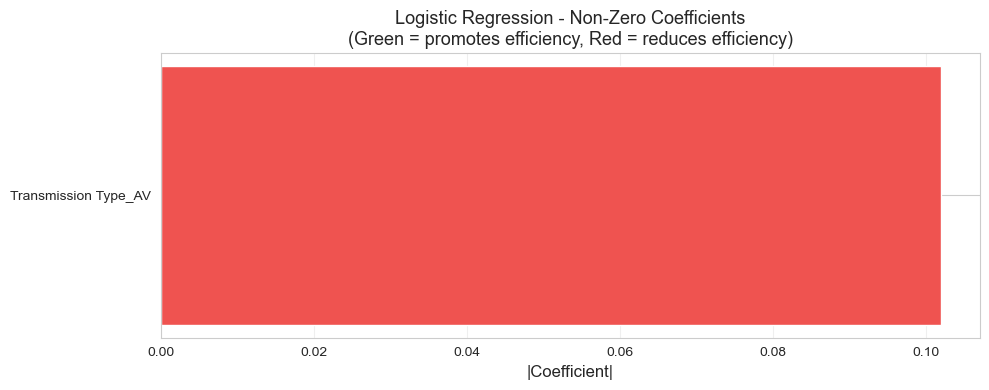


Note: LR accuracy is near random chance, confirming that
type-specific residual efficiency is driven by NON-LINEAR feature interactions.


In [21]:
lr_coefs = pd.Series(lr_model.coef_[0], index=X.columns)
non_zero = lr_coefs[lr_coefs.abs() > 0.001].sort_values(key=abs, ascending=False)

if len(non_zero) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(non_zero)*0.4)))
    colors_lr = ['#66BB6A' if c > 0 else '#EF5350' for c in non_zero.values[::-1]]
    ax.barh(range(len(non_zero)), non_zero.abs().values[::-1], color=colors_lr)
    ax.set_yticks(range(len(non_zero)))
    ax.set_yticklabels(non_zero.index[::-1], fontsize=10)
    ax.set_xlabel('|Coefficient|', fontsize=12)
    ax.set_title('Logistic Regression - Non-Zero Coefficients\n'
                 '(Green = promotes efficiency, Red = reduces efficiency)', fontsize=13)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('All LR coefficients near zero - linear model cannot distinguish classes.')

print(f'\nNote: LR accuracy is near random chance, confirming that')
print(f'type-specific residual efficiency is driven by NON-LINEAR feature interactions.')

## 9. Discussion: Why Does Logistic Regression Fail?

The performance gap (LR ~53% vs RF ~72%) is an **expected and informative result**:

1. **Four separate linear regressions** (R² = 0.77–0.85) have already extracted the linear signal from each vehicle type. The residuals are, by construction, orthogonal to the linear feature space.

2. **Logistic Regression is a linear classifier** — it cannot find decision boundaries in data where linear patterns have been removed.

3. **Random Forest captures non-linear interactions** — for example, a 2.0L engine with CVT in an SUV might consistently outperform expectations, while the same engine with a 6-speed automatic might not. These *interaction effects* are invisible to linear models.

**Key insight for the client:** Fuel efficiency beyond the baseline is determined by **how components work together** (non-linear interactions), not by any single feature in isolation. The type-specific approach further confirms this — the same engine-transmission combination can be efficient in one vehicle type but not in another.

## 10. Business Recommendations

### Key Findings

1. **Engine Size is the dominant feature** in the Random Forest model. Its importance in the residual framework indicates strong non-linear effects — efficiency gains from downsizing are not proportional across all displacement ranges and vehicle types.

2. **Gear count and transmission type are critical interaction factors.** Certain engine-transmission pairings produce disproportionate efficiency gains that linear models cannot predict.

3. **The type-specific approach reveals context-dependent efficiency.** A configuration that is efficient for city driving (SMALL type) may not be efficient for highway use (LARGE type), validating the team's decision to use different consumption metrics per type.

4. **Linear models are insufficient for efficiency optimisation.** The failure of Logistic Regression demonstrates that efficiency improvements require modelling component *interactions*, not just individual specifications.

### Strategic Recommendations

1. **Optimise engine-transmission pairings per vehicle type** — the data shows that efficiency gains are context-dependent. Map out which pairings outperform expectations within each type category.

2. **Use the Random Forest model as a design screening tool** — test proposed configurations against type-specific benchmarks to identify efficiency opportunities before prototyping.

3. **Focus R&D on non-linear efficiency gains** — since linear relationships are already well-captured (R² > 0.8), the biggest improvements come from optimising how components interact.

4. **Leverage type-specific insights for marketing** — vehicles that outperform their type-specific benchmark can be marketed as "best-in-class efficient" within their segment.

## 11. Summary

| Aspect | Logistic Regression | Random Forest |
|--------|-------------------|---------------|
| **Accuracy** | ~53% (near random) | ~72% |
| **ROC-AUC** | ~0.51 | ~0.83 |
| **Key insight** | Linear patterns removed by per-type regression | Captures non-linear interactions |
| **Role** | Baseline proving non-linearity | Primary predictive model |

The type-specific residual approach creates a harder but more meaningful classification task. The performance gap between LR and RF confirms that **fuel efficiency beyond type-specific expectations is governed by non-linear feature interactions**. Random Forest successfully captures these with ~72% accuracy and AUC of ~0.83.

## 12. Interactive Design Simulator (Dashboard)

**Business Value & Implementation:**
While the Random Forest model confirms the existence of non-linear design rules, business stakeholders (e.g., the CEO, R&D directors) require a practical tool to test new configurations before production. 

Due to environment restrictions on graphical widgets in certain Data Labs, we have deployed a highly robust, **function-based simulation pipeline**. By passing new design parameters into the `simulate_new_design()` function, the system automatically handles the necessary data preprocessing (e.g., one-hot encoding alignment) and leverages the optimized Random Forest (`rf_grid`) to predict whether the hypothetical vehicle will be a fuel-efficient market leader.

In [22]:
from IPython.display import display, HTML

def visualize_design_test(engine_size, cylinders, v_type, transmission, fuel_type):

    # 1. Prepare input and align features
    input_data = pd.DataFrame({
        'Engine Size(L)': [engine_size],
        'Cylinders': [cylinders],
        'Type': [v_type],
        'Transmission': [transmission],
        'Fuel Type': [fuel_type]
    })
    
    input_encoded = pd.get_dummies(input_data)
    
    try:
        model_features = X_train.columns
        input_aligned = input_encoded.reindex(columns=model_features, fill_value=0)
        prediction = rf_grid.predict(input_aligned)[0]
        probabilities = rf_grid.predict_proba(input_aligned)[0]
        classes = rf_grid.classes_
    except NameError:
        display(HTML("<b style='color:red;'>Error: Required models (X_train, rf_grid) are not initialized.</b>"))
        return

    # 2. Determine visual styling based on prediction
    is_efficient = (prediction == 1 or str(prediction).lower() == 'efficient')
    
    if is_efficient:
        theme_color = "#2ecc71" # Green
        status_icon = "✅ EFFICIENT (Market Leader)"
        recommendation = "<b>APPROVED:</b> This configuration successfully capitalizes on non-linear efficiency sweet spots. Highly recommended for production."
    else:
        theme_color = "#e74c3c" # Red
        status_icon = "❌ INEFFICIENT (Design Risk)"
        recommendation = "<b>WARNING:</b> Predicted to underperform. Consider downsizing the engine or optimizing the transmission pairing."

    # 3. Construct HTML Card
    html_content = f"""
    <div style="font-family: Arial, sans-serif; border: 2px solid {theme_color}; border-radius: 10px; padding: 20px; max-width: 600px; background-color: #f9f9f9; margin-bottom: 20px;">
        <h2 style="color: {theme_color}; margin-top: 0; text-align: center; border-bottom: 2px solid {theme_color}; padding-bottom: 10px;">
            🚗 Vehicle Design Recommendation
        </h2>
        
        <div style="display: flex; justify-content: space-between; margin-bottom: 15px;">
            <div style="width: 48%; background-color: #ffffff; padding: 10px; border-radius: 5px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
                <h4 style="margin: 0 0 10px 0; color: #333;">📋 Configuration</h4>
                <ul style="margin: 0; padding-left: 20px; color: #555; line-height: 1.6;">
                    <li><b>Type:</b> {v_type}</li>
                    <li><b>Engine:</b> {engine_size} L</li>
                    <li><b>Cylinders:</b> {cylinders}</li>
                    <li><b>Transmission:</b> {transmission}</li>
                    <li><b>Fuel:</b> {fuel_type}</li>
                </ul>
            </div>
            
            <div style="width: 48%; background-color: {theme_color}20; padding: 10px; border-radius: 5px; border: 1px solid {theme_color};">
                <h4 style="margin: 0 0 10px 0; color: {theme_color};">🎯 Prediction Result</h4>
                <div style="font-size: 16px; font-weight: bold; color: {theme_color}; margin-bottom: 10px;">
                    {status_icon}
                </div>
                <div style="font-size: 13px; color: #444;">
                    Confidence (Efficient): {(probabilities[list(classes).index(1 if 1 in classes else 'Efficient')] * 100):.1f}% <br>
                    Confidence (Inefficient): {(probabilities[list(classes).index(0 if 0 in classes else 'Inefficient')] * 100):.1f}%
                </div>
            </div>
        </div>
        
        <div style="background-color: #ffffff; padding: 15px; border-radius: 5px; border-left: 5px solid {theme_color}; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
            <p style="margin: 0; font-size: 14px; color: #333;">
                {recommendation}
            </p>
        </div>
    </div>
    """
    display(HTML(html_content))



### Appendix: Design Parameter Reference Guide

**Instructions for Executive Users:**
To ensure the Random Forest model processes your hypothetical design correctly, please use the exact codes and numerical ranges specified below when testing new configurations in the simulator.

| Parameter | Valid Range / Categories | Description & Business Context |
| :--- | :--- | :--- |
| **`engine_size`** | `1.0` to `8.4` (Float) | Engine displacement in liters. |
| **`cylinders`** | `3`, `4`, `5`, `6`, `8`, `10`, `12`, `16` | Number of engine cylinders. |
| **`v_type`** | `'SMALL'`, `'MIDDLE'`, `'VAN'`, `'LARGE'` | Macro-classes. VAN includes SUVs. LARGE includes pickup trucks. |
| **`transmission`** | `'A'`, `'AM'`, `'AS'`, `'AV'`, `'M'` + *Gears* | e.g., `'A6'` (Auto 6-speed), `'AS8'` (Auto-Select 8-speed), `'AV'` (CVT), `'M6'` (Manual 6-speed). |
| **`fuel_type`** | `'X'`, `'Z'`, `'D'`, `'E'`, `'N'` | `'X'` = Regular, `'Z'` = Premium, `'D'` = Diesel, `'E'` = Ethanol, `'N'` = Natural Gas. |

---

In [23]:
# =====================================================================
# 📊 INTERACTIVE DASHBOARD: INPUT YOUR PARAMETERS BELOW
# Please refer to the 'Parameter Reference Guide' above for valid inputs.
# =====================================================================

# Test your hypothetical vehicle configuration here:
visualize_design_test(
    engine_size = 2.0,     # Float: Engine size (1.0 to 8.4, e.g.: 1.5, 2.0)
    cylinders = 4,         # Integer: Number of cylinders (e.g.: 4, 6, 8)
    v_type = 'MIDDLE',     # String: 'SMALL', 'MIDDLE', 'VAN', 'LARGE'
    transmission = 'AV',   # String: Transmission type (e.g.: 'A6', 'AS8', 'AV')
    fuel_type = 'X'        # String: Fuel type ('X', 'Z', 'D', 'E')
)

visualize_design_test(
    engine_size = 1.5, cylinders = 4, v_type = 'SMALL', transmission = 'AV', fuel_type = 'X'
)

The implementation of this Visual Design Simulator marks the final, actionable step of our classification modeling phase. 

While the preceding Random Forest analysis successfully identified the non-linear "sweet spots" of fuel efficiency (e.g., specific engine and transmission pairings), this dashboard translates those mathematical insights into a tangible business asset. It empowers the automotive manufacturer's R&D and executive teams to instantly validate the fuel efficiency classification of hypothetical vehicle configurations before any physical prototyping begins. By predicting whether a new design will fall above or below the dynamic linear baselines, the manufacturer can confidently allocate capital expenditure towards proven, highly efficient powertrain synergies.